# Run-quality exploration

Sandbox for inspecting the per-run dataframe built by `analysis/run_quality.py`. The goal is to inform the schema for a future run-level materialized table by seeing which columns have signal and which thresholds are reasonable.

**Run order:** execute cells top-to-bottom. The first cell loads from the CSV produced by `uv run python analysis/run_quality.py`; if that file doesn't exist yet, run the script first.

In [1]:
import sys
from pathlib import Path

# Make the project root importable so we can call into src/ and analysis/
ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", rc={"figure.figsize": (9, 5)})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:
csv_path = ROOT / "analysis" / "run_quality.csv"
if not csv_path.exists():
    raise FileNotFoundError(
        f"{csv_path} not found. Run: uv run python analysis/run_quality.py"
    )

runs = pd.read_csv(
    csv_path,
    parse_dates=["run_start", "run_end"],
    dtype={"trip_id": str, "vehicle_id": str, "route_id": str, "stop_id": str},
)
runs["service_date"] = pd.to_datetime(runs["service_date"]).dt.date
print(f"{len(runs):,} runs, {runs['route_id'].nunique()} routes, "
      f"{runs['service_date'].min()} → {runs['service_date'].max()}")
print(f"is_complete: {runs['is_complete'].sum():,} ({runs['is_complete'].mean() * 100:.1f}%)")
runs.head()

21,686 runs, 137 routes, 2025-10-12 → 2025-10-21
is_complete: 8,525 (39.3%)


,run_id,trip_id,vehicle_id,route_id,service_date,n_pings,run_start,run_end,max_gap_sec,avg_speed_mps,actual_duration_sec,stops_observed,first_obs_seq,last_obs_seq,first_obs_dev_sec,last_obs_dev_sec,dev_p50_sec,dev_p95_sec,early_stops,on_time_stops,late_stops,stops_scheduled,sched_first_str,sched_last_str,coverage_pct,scheduled_duration_sec,is_complete
0,100010|0218|2025-10-12,100010,0218,31,2025-10-12,20,2025-10-12 17:29:22,2025-10-12 17:38:22,75.0,NaN,540.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.0,16:58:00,18:11:00,NaN,4380.0,False
1,100010|0230|2025-10-18,100010,0230,31,2025-10-18,104,2025-10-18 17:31:28,2025-10-18 18:23:00,103.0,2.965938,3092.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.0,16:58:00,18:11:00,NaN,4380.0,False
2,10002020|4691|2025-10-20,10002020,4691,F1X,2025-10-20,186,2025-10-20 09:49:14,2025-10-20 11:21:53,90.0,5.240594,5559.0,20.0,2.0,31.0,-35.0,31.0,-99.5,29.10,15.0,5.0,0.0,22.0,10:20:00,11:26:00,90.909091,3960.0,True
3,10003080|4615|2025-10-19,10003080,4615,D24,2025-10-19,130,2025-10-19 22:21:46,2025-10-19 23:26:15,252.0,4.473526,3869.0,33.0,2.0,59.0,56.0,35.0,-41.0,15.80,11.0,22.0,0.0,51.0,22:30:00,23:14:00,64.705882,2640.0,False
4,10004090|2988|2025-10-18,10004090,2988,A1X,2025-10-18,64,2025-10-18 22:04:10,2025-10-18 22:35:21,91.0,5.600700,1871.0,12.0,2.0,20.0,-39.0,18.0,18.0,70.95,2.0,10.0,0.0,15.0,22:10:00,22:36:00,80.000000,1560.0,True


## 1. Distributions of the candidate run-level columns

These plots are the first sanity check — does each column have a sensible distribution? Skewed or bimodal distributions are easier to spot here than in percentile printouts.

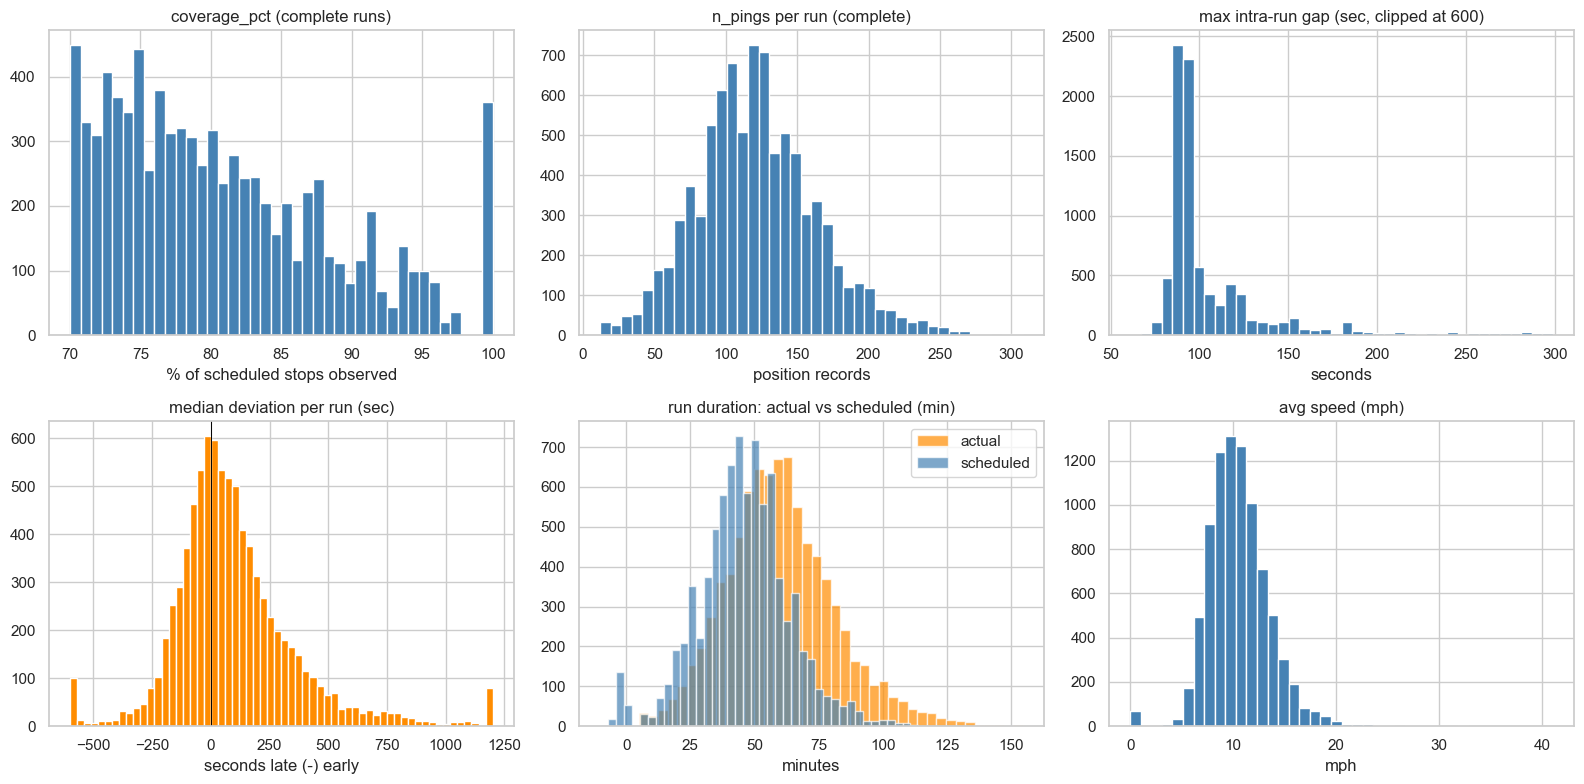

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

complete = runs[runs["is_complete"]]

axes[0, 0].hist(complete["coverage_pct"], bins=40, color="steelblue", edgecolor="white")
axes[0, 0].set_title("coverage_pct (complete runs)")
axes[0, 0].set_xlabel("% of scheduled stops observed")

axes[0, 1].hist(complete["n_pings"], bins=40, color="steelblue", edgecolor="white")
axes[0, 1].set_title("n_pings per run (complete)")
axes[0, 1].set_xlabel("position records")

axes[0, 2].hist(complete["max_gap_sec"].clip(upper=600), bins=40,
                color="steelblue", edgecolor="white")
axes[0, 2].set_title("max intra-run gap (sec, clipped at 600)")
axes[0, 2].set_xlabel("seconds")

axes[1, 0].hist(complete["dev_p50_sec"].clip(-600, 1200), bins=60,
                color="darkorange", edgecolor="white")
axes[1, 0].axvline(0, color="black", lw=0.7)
axes[1, 0].set_title("median deviation per run (sec)")
axes[1, 0].set_xlabel("seconds late (-) early")

axes[1, 1].hist(complete["actual_duration_sec"] / 60, bins=40,
                alpha=0.7, label="actual", color="darkorange")
axes[1, 1].hist(complete["scheduled_duration_sec"] / 60, bins=40,
                alpha=0.7, label="scheduled", color="steelblue")
axes[1, 1].set_title("run duration: actual vs scheduled (min)")
axes[1, 1].set_xlabel("minutes")
axes[1, 1].legend()

axes[1, 2].hist((complete["avg_speed_mps"] * 2.23694).dropna(), bins=40,
                color="steelblue", edgecolor="white")
axes[1, 2].set_title("avg speed (mph)")
axes[1, 2].set_xlabel("mph")

plt.tight_layout()
plt.show()

## 2. Sensitivity: how does `is_complete` count change with thresholds?

We currently flag a run complete if `coverage_pct >= 70` AND `first_obs_seq <= 3` AND `last_obs_seq >= stops_scheduled - 3` AND `max_gap_sec < 300`. This table sweeps the coverage threshold so you can see how many runs we keep / lose at each level.

In [4]:
# Recompute is_complete at varying coverage thresholds, holding other criteria fixed.
rows = []
for cov in (50, 60, 70, 80, 90):
    flag = (
        (runs["coverage_pct"] >= cov)
        & (runs["first_obs_seq"] <= 3)
        & (runs["last_obs_seq"] >= runs["stops_scheduled"] - 3)
        & (runs["max_gap_sec"].fillna(0) < 300)
    )
    sub = runs[flag]
    rows.append({
        "coverage_min": cov,
        "runs": int(flag.sum()),
        "pct_kept": flag.mean() * 100,
        "dev_p50_median_s": sub["dev_p50_sec"].median(),
        "dev_p95_median_s": sub["dev_p95_sec"].median(),
        "actual_min_median": (sub["actual_duration_sec"] / 60).median(),
    })
pd.DataFrame(rows)

,coverage_min,runs,pct_kept,dev_p50_median_s,dev_p95_median_s,actual_min_median
0,50,12793,58.991976,40.0,178.60,56.733333
1,60,11868,54.726552,44.0,186.55,57.416667
2,70,8525,39.311076,56.5,200.40,58.850000
3,80,4034,18.601863,62.0,208.70,58.758333
4,90,1295,5.971595,48.5,188.20,58.016667


## 3. Per-route comparison

How much do routes differ from each other? If there's no per-route signal, the run-level approach is overengineered.

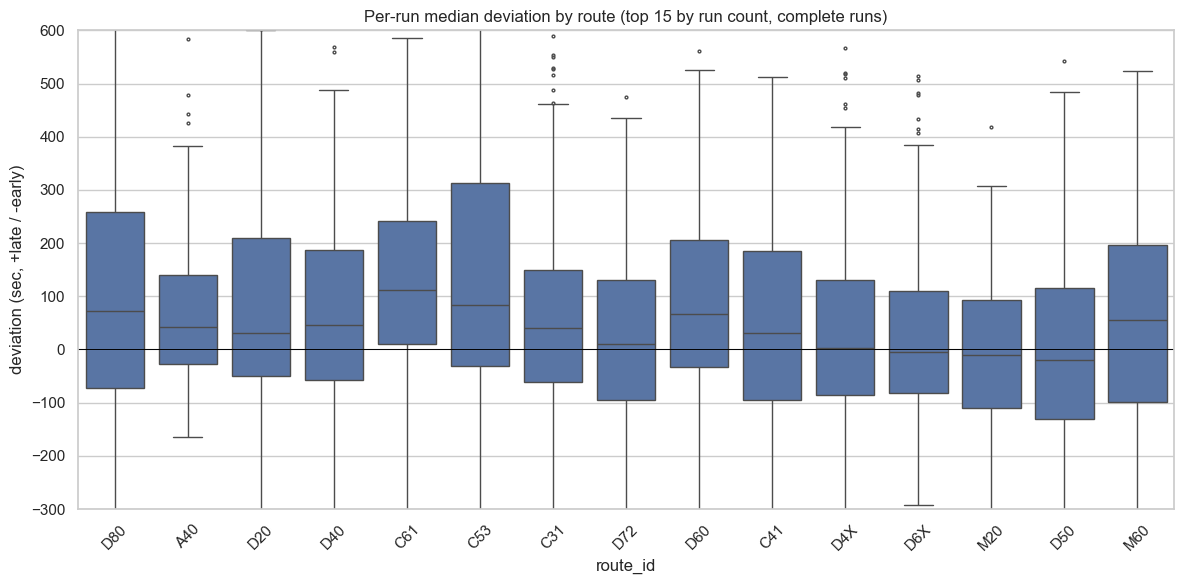

In [5]:
top_routes = (
    complete.groupby("route_id")
    .size()
    .sort_values(ascending=False)
    .head(15)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=complete[complete["route_id"].isin(top_routes)],
    x="route_id",
    y="dev_p50_sec",
    order=top_routes,
    ax=ax,
    fliersize=2,
)
ax.axhline(0, color="black", lw=0.7)
ax.set_ylim(-300, 600)
ax.set_title("Per-run median deviation by route (top 15 by run count, complete runs)")
ax.set_ylabel("deviation (sec, +late / -early)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Drill into one run

Plot deviation by `stop_sequence` for one specific run, so we can see the shape of how a bus drifts across its trip. This is the kind of view the per-run table makes possible that the daily batch can't.

In [6]:
from sqlalchemy import text
from src.database import get_session

# Pick a complete run on the busiest route on the fullest day.
candidate = (
    complete[(complete["route_id"] == "D80") & (complete["service_date"] == pd.to_datetime("2025-10-20").date())]
    .sort_values("n_pings", ascending=False)
    .head(1)
)
if candidate.empty:
    raise SystemExit("No matching run; pick another route/date by editing the cell.")

row = candidate.iloc[0]
print(f"trip_id={row['trip_id']} vehicle={row['vehicle_id']} date={row['service_date']}")

db = get_session()
try:
    positions = pd.read_sql(
        text(
            """
            SELECT timestamp, stop_id, current_stop_sequence, current_status
            FROM vehicle_positions
            WHERE trip_id = :tid AND vehicle_id = :vid AND DATE(timestamp) = :d
            ORDER BY timestamp
            """
        ),
        db.bind,
        params={"tid": row["trip_id"], "vid": row["vehicle_id"], "d": row["service_date"]},
    )
    schedule = pd.read_sql(
        text(
            """
            SELECT stop_sequence, stop_id, arrival_time
            FROM stop_times
            WHERE trip_id = :tid AND is_current = true
            ORDER BY stop_sequence
            """
        ),
        db.bind,
        params={"tid": row["trip_id"]},
    )
finally:
    db.close()

trip_id=4103020 vehicle=4571 date=2025-10-20


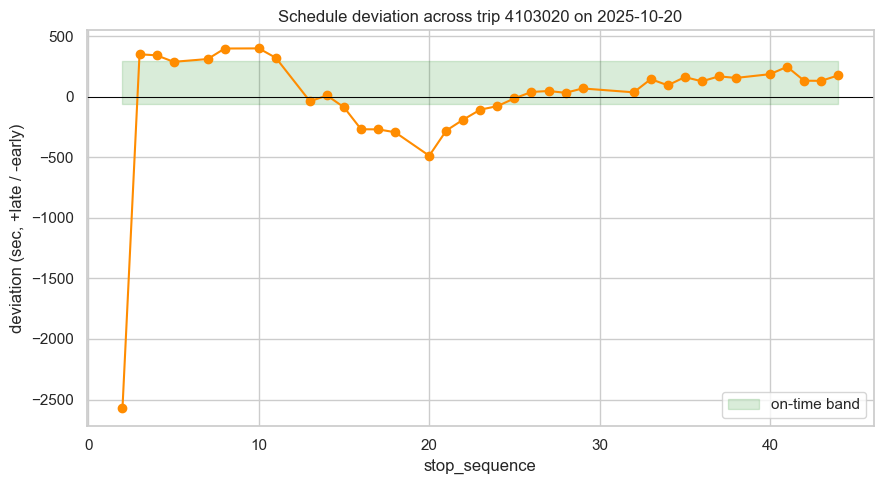

,stop_sequence,stop_id,timestamp,scheduled,deviation_sec
10,2,28329,2025-10-20 15:32:10,2025-10-20 16:15:00,-2570.0
12,3,29020,2025-10-20 16:27:16,2025-10-20 16:21:24,352.0
13,4,5777,2025-10-20 16:28:24,2025-10-20 16:22:40,344.0
11,5,28331,2025-10-20 16:30:23,2025-10-20 16:25:33,290.0
1,7,17171,2025-10-20 16:33:31,2025-10-20 16:28:18,313.0
15,8,5947,2025-10-20 16:36:27,2025-10-20 16:29:47,400.0
9,10,28327,2025-10-20 16:37:41,2025-10-20 16:31:00,401.0
16,11,5948,2025-10-20 16:40:40,2025-10-20 16:35:17,323.0
14,13,5946,2025-10-20 16:42:24,2025-10-20 16:43:00,-36.0
7,14,28077,2025-10-20 16:44:43,2025-10-20 16:44:31,12.0


In [7]:
# First ping at each stop within the run.
obs = positions.dropna(subset=["stop_id"]).copy()
obs = obs[obs["stop_id"] != ""]
rank = {1: 0, 2: 1}  # STOPPED_AT > IN_TRANSIT_TO
obs["rank"] = obs["current_status"].map(rank).fillna(2).astype(int)
first = (
    obs.sort_values(["stop_id", "rank", "timestamp"])
    .drop_duplicates("stop_id", keep="first")
)

merged = first.merge(schedule, on="stop_id", how="inner")

def parse_gtfs(t, d):
    h, m, s = (int(x) for x in t.split(":"))
    extra, h = divmod(h, 24)
    return pd.Timestamp(d) + pd.Timedelta(days=extra, hours=h, minutes=m, seconds=s)

merged["scheduled"] = merged["arrival_time"].apply(lambda t: parse_gtfs(t, row["service_date"]))
merged["deviation_sec"] = (merged["timestamp"] - merged["scheduled"]).dt.total_seconds()
merged = merged.sort_values("stop_sequence")

fig, ax = plt.subplots()
ax.plot(merged["stop_sequence"], merged["deviation_sec"], marker="o", color="darkorange")
ax.axhline(0, color="black", lw=0.7)
ax.fill_between([merged["stop_sequence"].min(), merged["stop_sequence"].max()],
                -60, 300, alpha=0.15, color="green", label="on-time band")
ax.set_xlabel("stop_sequence")
ax.set_ylabel("deviation (sec, +late / -early)")
ax.set_title(f"Schedule deviation across trip {row['trip_id']} on {row['service_date']}")
ax.legend()
plt.tight_layout()
plt.show()

merged[["stop_sequence", "stop_id", "timestamp", "scheduled", "deviation_sec"]].head(10)

## 5. Time-of-day patterns

Does deviation worsen at peak hours? If so, that justifies adding a `time_period` dimension to the schema rather than only `service_date`.

In [8]:
complete_with_hour = complete.copy()
complete_with_hour["hour"] = pd.to_datetime(complete_with_hour["run_start"]).dt.hour
by_hour = (
    complete_with_hour.groupby("hour")["dev_p50_sec"]
    .agg(["count", "median", lambda s: float(np.percentile(s, 95))])
    .rename(columns={"<lambda_0>": "p95"})
)
by_hour

,count,median,p95
hour,,,
0,94,-86232.75,94.000
1,25,42.00,416.000
2,31,49.50,478.000
3,36,86.50,721.500
4,89,24.00,486.700
5,233,36.00,438.000
6,351,41.00,498.750
7,456,56.50,501.250
8,386,47.75,585.625


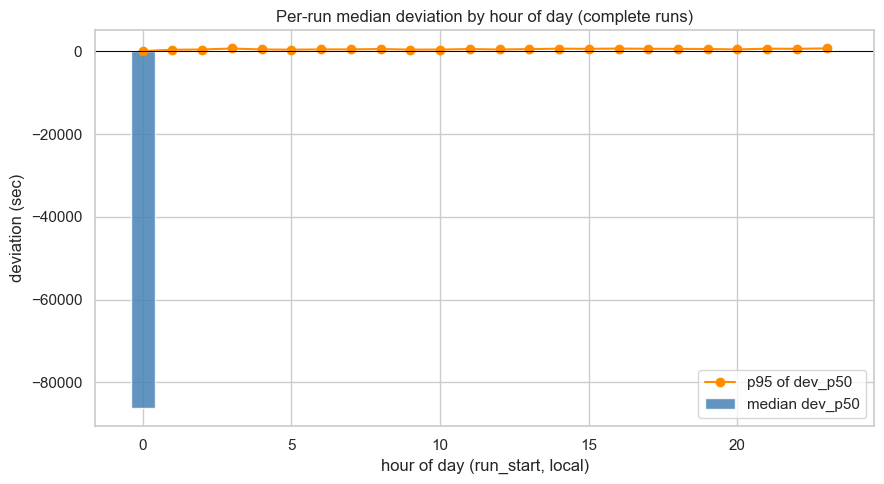

In [9]:
fig, ax = plt.subplots()
ax.bar(by_hour.index, by_hour["median"], color="steelblue", alpha=0.85, label="median dev_p50")
ax.plot(by_hour.index, by_hour["p95"], color="darkorange", marker="o", label="p95 of dev_p50")
ax.axhline(0, color="black", lw=0.7)
ax.set_xlabel("hour of day (run_start, local)")
ax.set_ylabel("deviation (sec)")
ax.set_title("Per-run median deviation by hour of day (complete runs)")
ax.legend()
plt.tight_layout()
plt.show()

## Open questions to chew on

1. Is the 70%-coverage threshold for `is_complete` right? See section 2.
2. The boxplot in section 3 — are the per-route differences meaningful or noise from small samples?
3. Does the per-run drift profile in section 4 look like real bus behavior (late-then-recovers, accumulating drift, etc.)?
4. Section 5: if peak hours look distinct, the materialized table should track time-period. If not, drop it.